<a href="https://colab.research.google.com/github/saixg/MLE-EDA-EXPLORER/blob/main/titanic(binary%20classif)/mle_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import all libraries needed for this notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="muted")

# Load the Titanic dataset directly from seaborn
titanic = sns.load_dataset('titanic')

# Quick sanity check
print("Shape:", titanic.shape)
print("\nFirst 5 rows:")
titanic.head()

Shape: (891, 15)

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# Separate features (X) and label (y)
cols_to_drop = ['survived', 'alive', 'who', 'adult_male',
                'alone', 'deck', 'embark_town']

X = titanic.drop(columns=cols_to_drop)
y = titanic['survived']

print("Label (y): 'survived'  →  0 = died, 1 = survived")
print(f"\nFeatures (X) — {len(X.columns)} columns:")
print(X.columns.tolist())

print("\n--- Data types ---")
print(X.dtypes)

print("\nNumerical features: ", X.select_dtypes(include='number').columns.tolist())
print("Categorical features:", X.select_dtypes(include='object').columns.tolist())

Label (y): 'survived'  →  0 = died, 1 = survived

Features (X) — 8 columns:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class']

--- Data types ---
pclass         int64
sex           object
age          float64
sibsp          int64
parch          int64
fare         float64
embarked      object
class       category
dtype: object

Numerical features:  ['pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical features: ['sex', 'embarked']


             missing_count  missing_pct
deck                   688         77.2
age                    177         19.9
embarked                 2          0.2
embark_town              2          0.2


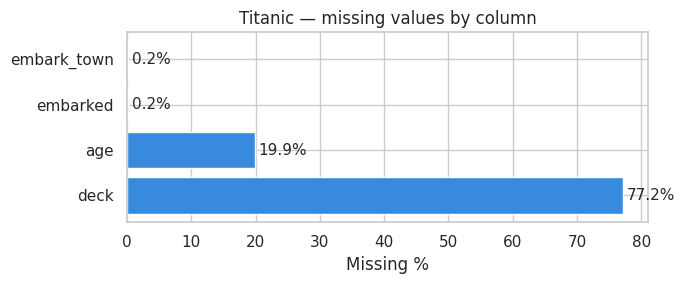

In [ ]:
# Check missing values in the full titanic dataframe
missing = titanic.isnull().sum()
pct     = (missing / len(titanic) * 100).round(1)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct':   pct
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

print(missing_df.to_string())

# Visualise as a bar chart
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(missing_df.index, missing_df['missing_pct'], color='#378ADD')
ax.set_xlabel('Missing %')
ax.set_title('Titanic — missing values by column')
for i, v in enumerate(missing_df['missing_pct']):
    ax.text(v + 0.5, i, f'{v}%', va='center', fontsize=11)
plt.tight_layout(); plt.show()


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Survived: 342 (38.4%)
Died:     549 (61.6%)


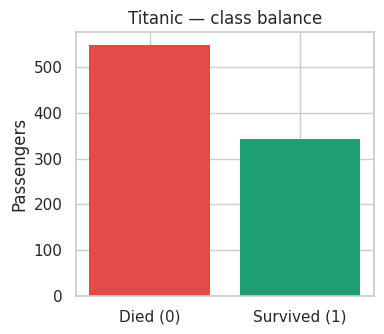

In [ ]:
# Descriptive statistics for numerical columns
display(titanic.describe())

# Class balance
balance = y.value_counts()
pct_survived = (y.mean() * 100).round(1)

print(f"\nSurvived: {balance[1]} ({pct_survived}%)")
print(f"Died:     {balance[0]} ({100 - pct_survived}%)")

fig, ax = plt.subplots(figsize=(4, 3.5))
ax.bar(['Died (0)', 'Survived (1)'], balance.values[[0, 1]],
      color=['#E24B4A', '#1D9E75'], edgecolor='none')
ax.set_title('Titanic — class balance')
ax.set_ylabel('Passengers')
plt.tight_layout(); plt.show()

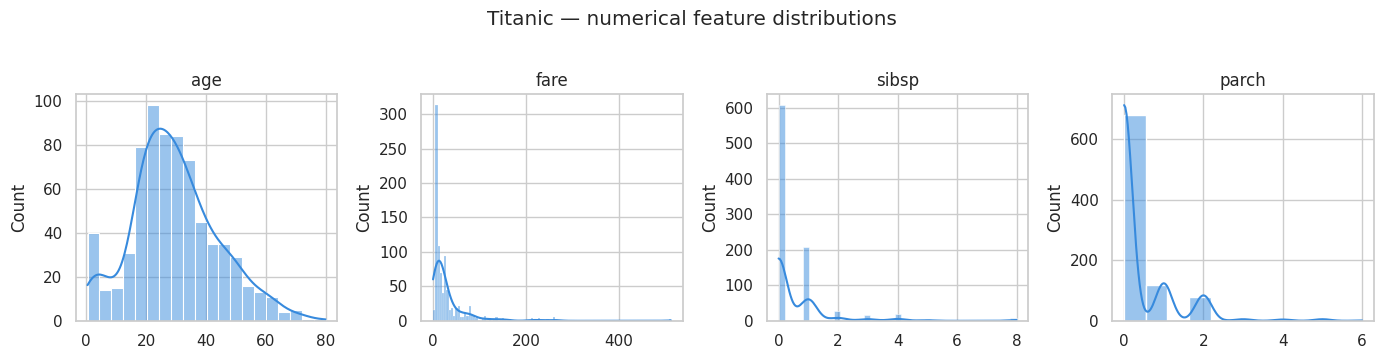

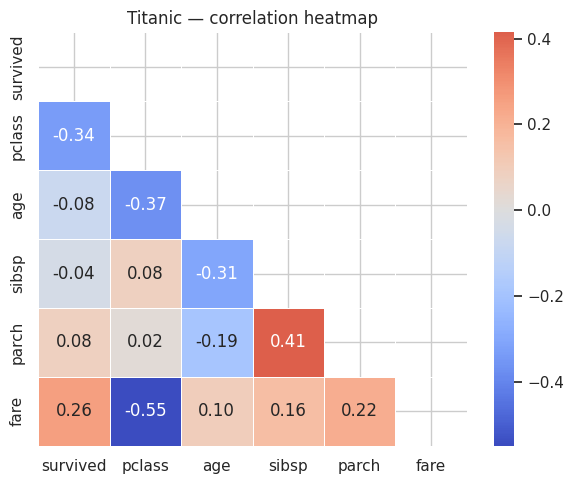

/tmp/ipykernel_1135/82966804.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic, x='sex', y='survived',
/tmp/ipykernel_1135/82966804.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic, x='pclass', y='survived',


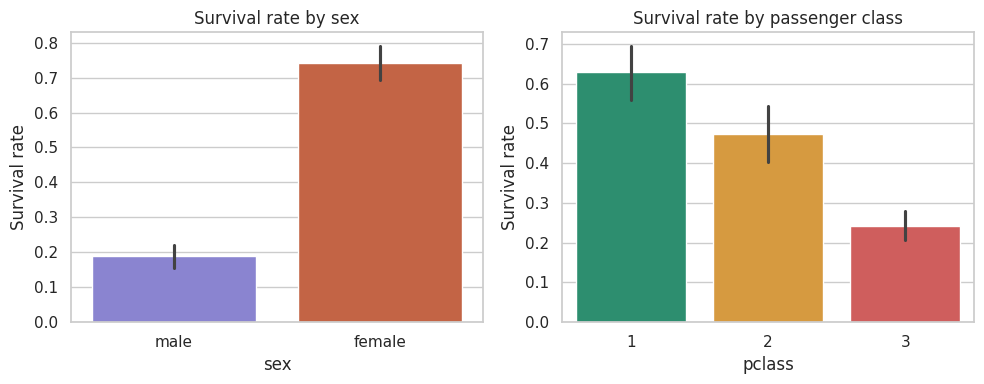

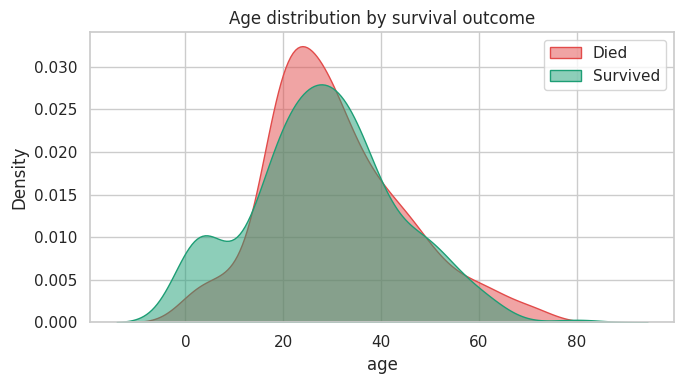

In [ ]:
# --- 1. Feature distributions (numerical) ---
num_cols = ['age', 'fare', 'sibsp', 'parch']
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, col in zip(axes, num_cols):
    sns.histplot(titanic[col].dropna(), kde=True, ax=ax, color='#378ADD')
    ax.set_title(col); ax.set_xlabel("")
fig.suptitle('Titanic — numerical feature distributions', y=1.02)
plt.tight_layout(); plt.show()

# --- 2. Correlation heatmap ---
fig, ax = plt.subplots(figsize=(6, 5))
corr = titanic.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax, linewidths=0.5)
ax.set_title('Titanic — correlation heatmap')
plt.tight_layout(); plt.show()

# --- 3. Survival by sex and pclass (most predictive features) ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(data=titanic, x='sex', y='survived',
             palette=['#7F77DD', '#D85A30'], ax=axes[0])
axes[0].set_title('Survival rate by sex')
axes[0].set_ylabel('Survival rate')

sns.barplot(data=titanic, x='pclass', y='survived',
             palette=['#1D9E75', '#EF9F27', '#E24B4A'], ax=axes[1])
axes[1].set_title('Survival rate by passenger class')
axes[1].set_ylabel('Survival rate')

plt.tight_layout(); plt.show()

# --- 4. Age distribution by survival ---
fig, ax = plt.subplots(figsize=(7, 4))
for val, label, color in [(0, 'Died', '#E24B4A'), (1, 'Survived', '#1D9E75')]:
    sns.kdeplot(titanic[titanic.survived==val]['age'].dropna(),
                fill=True, label=label, color=color, alpha=0.5, ax=ax)
ax.set_title('Age distribution by survival outcome')
ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
# Keep only the columns we'll actually feed into a model
model_cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

titanic_clean = titanic[model_cols + ['survived']].dropna()

X_clean = titanic_clean[model_cols]
y_clean = titanic_clean['survived']

# 70/30 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.30,
    random_state=42,
    stratify=y_clean
)

print("=== Titanic 70/30 Split ===")
print(f"X_train : {X_train.shape}   X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}   y_test : {y_test.shape}")
print(f"\nTrain survival rate : {y_train.mean():.3f}")
print(f"Test  survival rate : {y_test.mean():.3f}  ← should match (stratified)")

=== Titanic 70/30 Split ===
X_train : (498, 7)   X_test : (214, 7)
y_train : (498,)   y_test : (214,)

Train survival rate : 0.404
Test  survival rate : 0.407  ← should match (stratified)


In [ ]:
## Final EDA report — Titanic
### Data quality
"""age — ~20% missing → impute with median before modeling
embarked — 2 missing → impute with mode ('S')
deck — 77% missing → drop
### Key insights from EDA
Sex is the strongest predictor — female survival rate ~74% vs male ~19%
Pclass matters — 1st class survived at ~63%, 3rd class at ~24%
Age — children had slightly higher survival; very slight KDE separation
Fare is right-skewed with outliers — consider log-transform
Mild class imbalance (~38% survived) — use class_weight='balanced' or stratified splits
 """